# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura(mode=3) # Leyendo 3 primeros individuos
df_val = dp.lectura(mode=4) # Leyendo 10mo individuo

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [4]:
del df
del df_val

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     348
0     348
3     348
4     348
6     348
9     348
10    348
11    348
Name: count, dtype: int64
stimulus
1     72
3     72
0     72
4     72
6     72
9     72
10    72
11    72
Name: count, dtype: int64


# Filtro

In [6]:
df_block_filtered = dp.filter(df_block)
df_block_filtered_val = dp.filter(df_block_val)

Procesando: 100%|██████████| 3/3 [00:16<00:00,  5.35s/it]


In [7]:
del df_block
del df_block_val

# Extracción de características

In [8]:
scaler, df_block_features = dp.get_carac(df_block_filtered)
df_block_features_val = dp.get_carac(df_block_filtered_val, scaler)

Extrayendo Características: 100%|██████████| 576/576 [01:19<00:00,  7.22it/s]


In [9]:
del df_block_filtered
del df_block_filtered_val

In [10]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,...,2784.000000,2.784000e+03,2784.000000,2784.000000,2784.00000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000
mean,0.000033,0.184108,0.000019,0.089507,0.000016,0.097430,0.000010,0.037320,0.000008,0.052923,...,0.000230,1.850889e-13,241.248223,69.058190,1529.29023,8.737787,96.367295,6.562593,0.153205,5.500000
std,0.000015,0.085296,0.000008,0.048381,0.000008,0.046816,0.000005,0.018757,0.000004,0.029171,...,0.000420,6.171145e-12,48.800620,27.582852,387.39429,5.868685,65.004459,6.019121,0.101488,3.905826
min,0.000003,0.021203,0.000002,0.008854,0.000002,0.013957,0.000002,0.005685,0.000001,0.007699,...,0.000002,5.097387e-19,72.434757,14.000000,489.00000,0.000000,21.309371,1.451933,0.061021,0.000000
25%,0.000022,0.122593,0.000013,0.055614,0.000011,0.064815,0.000007,0.024117,0.000004,0.029921,...,0.000005,6.200348e-18,201.251010,46.000000,1249.00000,4.000000,45.314565,2.285554,0.094104,2.500000
50%,0.000030,0.168835,0.000018,0.078708,0.000016,0.093935,0.000010,0.036103,0.000007,0.045187,...,0.000201,1.435972e-14,221.758956,58.000000,1415.00000,7.000000,73.672921,5.443195,0.127018,5.000000
75%,0.000040,0.231745,0.000024,0.113155,0.000020,0.122930,0.000013,0.047379,0.000010,0.069685,...,0.000357,4.996896e-14,297.074874,100.000000,1944.00000,13.000000,147.322897,8.702973,0.184275,9.250000
max,0.000121,0.667137,0.000066,0.389030,0.000129,0.526642,0.000056,0.215007,0.000035,0.201035,...,0.014789,3.228745e-10,306.733169,112.000000,2227.00000,34.000000,313.287017,88.398970,1.907691,11.000000


In [11]:
df_block_features_val.describe()

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,...,576.000000,5.760000e+02,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,0.000052,0.275515,0.000029,0.125815,0.000048,0.278885,0.000030,0.113803,0.000020,0.116331,...,0.000005,5.038409e-18,297.532394,100.654514,1956.550347,13.857639,154.063767,2.269221,0.094255,5.500000
std,0.000047,0.175544,0.000018,0.069679,0.000023,0.116980,0.000012,0.054951,0.000018,0.079528,...,0.000001,2.166521e-18,2.350912,2.649446,205.739973,4.577511,65.403123,0.422262,0.006904,3.908519
min,0.000011,0.055570,0.000007,0.021893,0.000009,0.050414,0.000005,0.016981,0.000004,0.027493,...,0.000002,9.442171e-19,287.020812,92.000000,1098.000000,4.000000,29.694128,1.386501,0.078948,0.000000
25%,0.000030,0.170562,0.000018,0.075218,0.000034,0.197856,0.000021,0.074718,0.000011,0.068885,...,0.000004,3.402812e-18,296.069089,99.000000,1905.750000,11.000000,94.272125,1.978178,0.089620,2.500000
50%,0.000041,0.232990,0.000025,0.108813,0.000046,0.274550,0.000029,0.110948,0.000015,0.091722,...,0.000005,4.584089e-18,297.662241,101.000000,1996.000000,13.000000,147.624813,2.205925,0.093513,5.000000
75%,0.000061,0.330048,0.000035,0.159863,0.000059,0.353544,0.000037,0.144455,0.000022,0.131917,...,0.000005,6.077952e-18,299.022175,102.000000,2111.000000,17.000000,221.454821,2.470877,0.097631,9.250000
max,0.000421,1.459593,0.000156,0.419193,0.000294,0.737629,0.000097,0.394803,0.000154,0.581695,...,0.000007,1.058739e-17,305.212830,109.000000,2225.000000,30.000000,304.648863,4.187807,0.133558,11.000000


# Normalización

In [12]:
scaler, df_block_normalized = dp.normalize(df_block_features)
df_block_normalized_val = dp.normalize(df_block_features_val, scaler)

In [13]:
del df_block_features
del df_block_features_val

In [14]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,...,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2784.000000
mean,2.041789e-17,-9.188053e-17,-1.020895e-17,-1.633432e-16,3.266863e-16,-2.858505e-16,-1.225074e-16,1.837611e-16,-1.633432e-16,-1.225074e-16,...,2.041789e-17,-7.656711e-18,-3.266863e-16,4.083579e-17,8.167158e-17,8.167158e-17,-2.450147e-16,1.429253e-16,-1.837611e-16,5.500000
std,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,...,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,3.905826
min,-1.988892e+00,-1.910213e+00,-2.046756e+00,-1.667338e+00,-1.740774e+00,-1.783337e+00,-1.801996e+00,-1.686881e+00,-1.491811e+00,-1.550580e+00,...,-5.438345e-01,-2.999794e-02,-3.459870e+00,-1.996461e+00,-2.685835e+00,-1.489151e+00,-1.154866e+00,-8.492233e-01,-9.084828e-01,0.000000
25%,-7.184721e-01,-7.213258e-01,-7.371689e-01,-7.006636e-01,-6.417939e-01,-6.967951e-01,-6.917545e-01,-7.040377e-01,-8.093493e-01,-7.886694e-01,...,-5.349886e-01,-2.999702e-02,-8.197519e-01,-8.361112e-01,-7.236570e-01,-8.074447e-01,-7.855138e-01,-7.107030e-01,-5.824445e-01,2.500000
50%,-2.132692e-01,-1.790952e-01,-1.668215e-01,-2.232575e-01,-5.379686e-02,-7.466661e-02,-4.539226e-02,-6.491541e-02,-2.173899e-01,-2.652379e-01,...,-7.011334e-02,-2.767069e-02,-3.994369e-01,-4.009802e-01,-2.950760e-01,-2.961651e-01,-3.491830e-01,-1.860070e-01,-2.580738e-01,5.000000
75%,4.592871e-01,5.585779e-01,5.606177e-01,4.888686e-01,4.547567e-01,5.447674e-01,5.287340e-01,5.363746e-01,5.894192e-01,5.746977e-01,...,3.018771e-01,-2.189937e-02,1.144180e+00,1.121979e+00,1.070703e+00,7.263942e-01,7.840194e-01,3.556606e-01,3.061994e-01,9.250000
max,5.750061e+00,5.663955e+00,5.517032e+00,6.192006e+00,1.392266e+01,9.169703e+00,9.685820e+00,9.474692e+00,6.172460e+00,5.078208e+00,...,3.466199e+01,5.229943e+01,1.342129e+00,1.557110e+00,1.801356e+00,4.305352e+00,3.337597e+00,1.359851e+01,1.729071e+01,11.000000


In [15]:
df_block_normalized_val.describe()

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,...,576.000000,5.760000e+02,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,1.219297,1.071826,1.146057,0.750585,3.890318,3.876610,4.048518,4.078266,2.797859,2.174019,...,-0.536478,-2.999720e-02,1.153557,1.145712,1.103106,0.872559,0.887737,-0.713417,-0.580959,5.500000
std,3.056261,2.058417,2.120387,1.440460,2.829187,2.499175,2.557504,2.930102,4.083609,2.726729,...,0.002430,3.511358e-07,0.048182,0.096071,0.531182,0.780129,1.006314,0.070166,0.068041,3.908519
min,-1.446994,-1.507236,-1.519517,-1.397779,-0.907337,-1.004457,-1.117595,-1.084532,-0.796030,-0.871912,...,-0.543242,-2.999787e-02,0.938119,0.831891,-1.113511,-0.807445,-1.025855,-0.860096,-0.731816,0.000000
25%,-0.167700,-0.158847,-0.138001,-0.295395,2.150553,2.145513,2.219756,1.994144,0.647327,0.547290,...,-0.538263,-2.999747e-02,1.123566,1.085718,0.971949,0.385541,-0.032237,-0.761779,-0.626637,2.500000
50%,0.544940,0.573184,0.641267,0.399115,3.666138,3.784004,3.949798,3.926017,1.515352,1.330261,...,-0.536745,-2.999728e-02,1.156218,1.158240,1.204957,0.726394,0.788665,-0.723935,-0.588272,5.000000
75%,1.859640,1.711271,1.873743,1.454455,5.215143,5.471640,5.672934,5.712684,3.144542,2.708422,...,-0.534978,-2.999704e-02,1.184090,1.194500,1.501866,1.408100,1.924637,-0.679908,-0.547690,9.250000
max,25.394928,14.956232,16.239538,6.815559,34.304413,13.677257,18.253469,19.061872,33.238217,18.129618,...,-0.530631,-2.999630e-02,1.310969,1.448327,1.796193,3.623645,3.204688,-0.394611,-0.193623,11.000000


# Creación de dataframes de entrenamiento y testeo

In [16]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [17]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [18]:
del df_block_normalized
del df_block_normalized_val

In [19]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(1948, 183) (1948,)
(576, 183) (576,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [20]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [21]:
# Visualization libraries

import seaborn as sns

Random forest

In [22]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [23]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [24]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step


# Resultados

Random forest

Test data

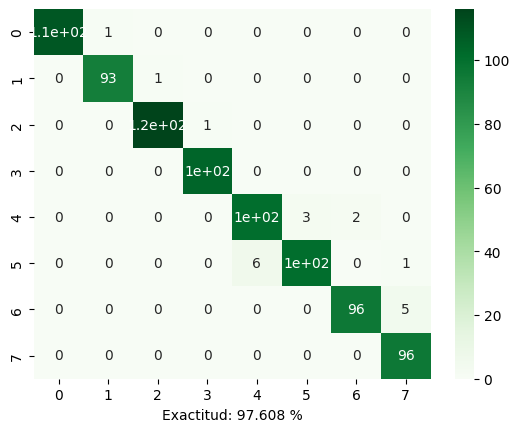

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       110
           1       0.99      0.99      0.99        94
           3       0.99      0.99      0.99       117
           4       0.99      1.00      1.00       104
           6       0.94      0.95      0.95       106
           9       0.97      0.94      0.95       108
          10       0.98      0.95      0.96       101
          11       0.94      1.00      0.97        96

    accuracy                           0.98       836
   macro avg       0.98      0.98      0.98       836
weighted avg       0.98      0.98      0.98       836



In [25]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

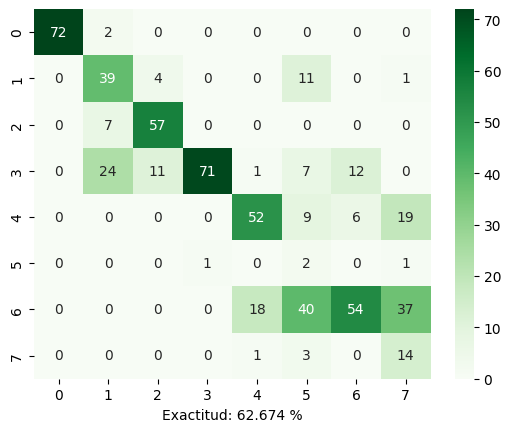

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        74
           1       0.54      0.71      0.61        55
           3       0.79      0.89      0.84        64
           4       0.99      0.56      0.72       126
           6       0.72      0.60      0.66        86
           9       0.03      0.50      0.05         4
          10       0.75      0.36      0.49       149
          11       0.19      0.78      0.31        18

    accuracy                           0.63       576
   macro avg       0.63      0.67      0.58       576
weighted avg       0.79      0.63      0.67       576



In [26]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

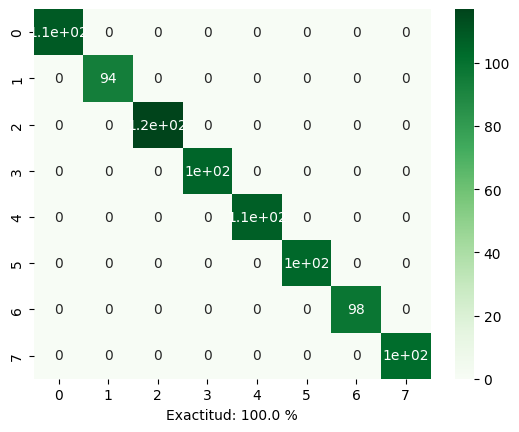

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        94
           3       1.00      1.00      1.00       117
           4       1.00      1.00      1.00       105
           6       1.00      1.00      1.00       107
           9       1.00      1.00      1.00       104
          10       1.00      1.00      1.00        98
          11       1.00      1.00      1.00       102

    accuracy                           1.00       836
   macro avg       1.00      1.00      1.00       836
weighted avg       1.00      1.00      1.00       836



In [27]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

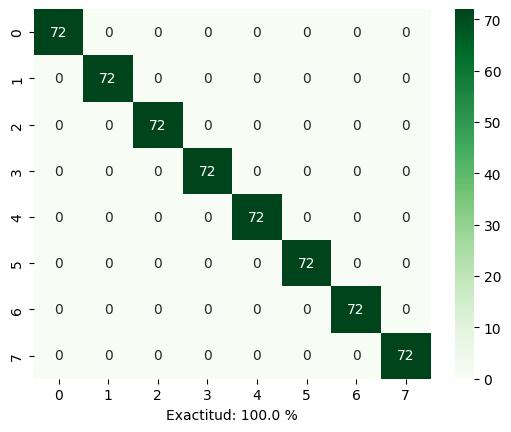

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        72
           3       1.00      1.00      1.00        72
           4       1.00      1.00      1.00        72
           6       1.00      1.00      1.00        72
           9       1.00      1.00      1.00        72
          10       1.00      1.00      1.00        72
          11       1.00      1.00      1.00        72

    accuracy                           1.00       576
   macro avg       1.00      1.00      1.00       576
weighted avg       1.00      1.00      1.00       576



In [28]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

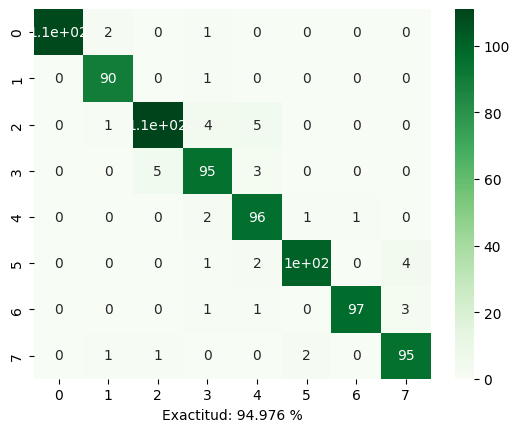

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       112
           1       0.96      0.99      0.97        91
           3       0.95      0.92      0.93       121
           4       0.90      0.92      0.91       103
           6       0.90      0.96      0.93       100
           9       0.97      0.94      0.95       108
          10       0.99      0.95      0.97       102
          11       0.93      0.96      0.95        99

    accuracy                           0.95       836
   macro avg       0.95      0.95      0.95       836
weighted avg       0.95      0.95      0.95       836



In [29]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

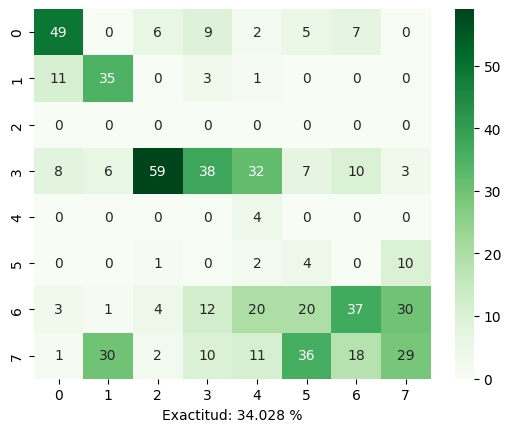

              precision    recall  f1-score   support

           0       0.68      0.63      0.65        78
           1       0.49      0.70      0.57        50
           3       0.00      0.00      0.00         0
           4       0.53      0.23      0.32       163
           6       0.06      1.00      0.11         4
           9       0.06      0.24      0.09        17
          10       0.51      0.29      0.37       127
          11       0.40      0.21      0.28       137

    accuracy                           0.34       576
   macro avg       0.34      0.41      0.30       576
weighted avg       0.49      0.34      0.38       576



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [30]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [31]:
pca = PCA(n_components=0.8)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca.transform(X_val)

In [32]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(2784, 183)
(2784, 27)
Con PCA
(576, 183)
(576, 27)


Random forest

In [33]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [34]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [35]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


# Resultados

Random forest

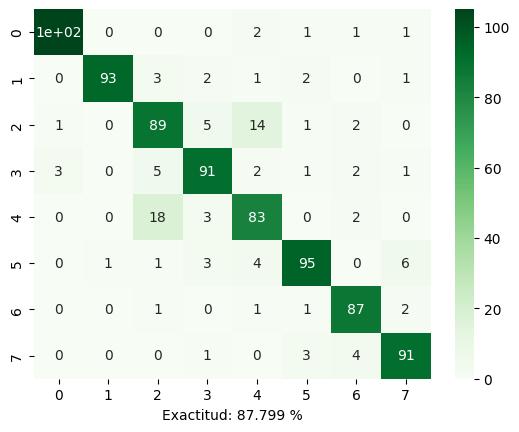

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       110
           1       0.99      0.91      0.95       102
           3       0.76      0.79      0.78       112
           4       0.87      0.87      0.87       105
           6       0.78      0.78      0.78       106
           9       0.91      0.86      0.89       110
          10       0.89      0.95      0.92        92
          11       0.89      0.92      0.91        99

    accuracy                           0.88       836
   macro avg       0.88      0.88      0.88       836
weighted avg       0.88      0.88      0.88       836



In [36]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

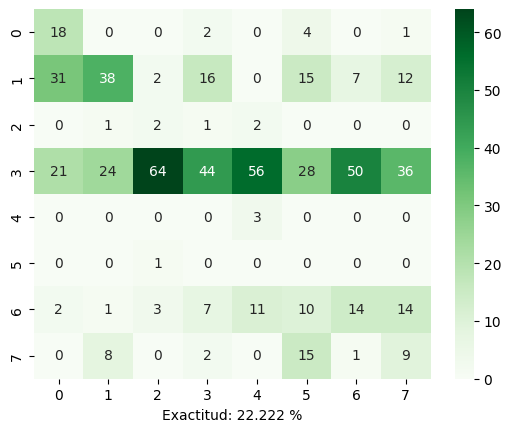

              precision    recall  f1-score   support

           0       0.25      0.72      0.37        25
           1       0.53      0.31      0.39       121
           3       0.03      0.33      0.05         6
           4       0.61      0.14      0.22       323
           6       0.04      1.00      0.08         3
           9       0.00      0.00      0.00         1
          10       0.19      0.23      0.21        62
          11       0.12      0.26      0.17        35

    accuracy                           0.22       576
   macro avg       0.22      0.37      0.19       576
weighted avg       0.49      0.22      0.26       576



In [37]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

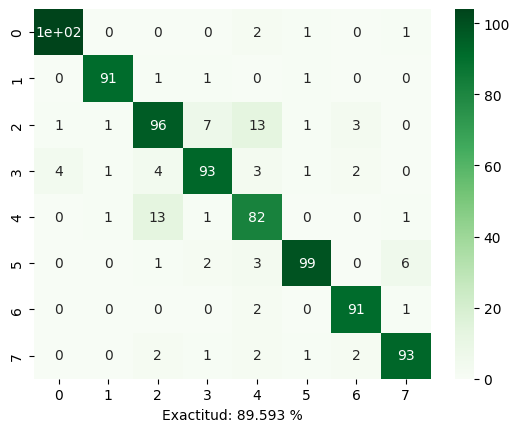

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       108
           1       0.97      0.97      0.97        94
           3       0.82      0.79      0.80       122
           4       0.89      0.86      0.87       108
           6       0.77      0.84      0.80        98
           9       0.95      0.89      0.92       111
          10       0.93      0.97      0.95        94
          11       0.91      0.92      0.92       101

    accuracy                           0.90       836
   macro avg       0.90      0.90      0.90       836
weighted avg       0.90      0.90      0.90       836



In [38]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

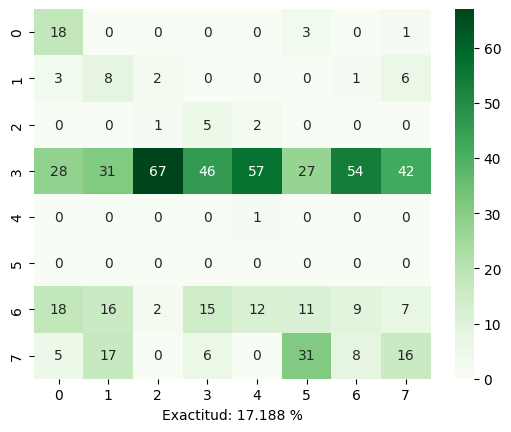

              precision    recall  f1-score   support

           0       0.25      0.82      0.38        22
           1       0.11      0.40      0.17        20
           3       0.01      0.12      0.03         8
           4       0.64      0.13      0.22       352
           6       0.01      1.00      0.03         1
           9       0.00      0.00      0.00         0
          10       0.12      0.10      0.11        90
          11       0.22      0.19      0.21        83

    accuracy                           0.17       576
   macro avg       0.17      0.35      0.14       576
weighted avg       0.46      0.17      0.20       576



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [39]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

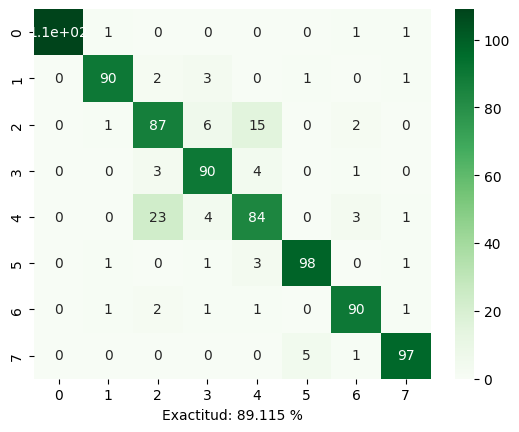

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       112
           1       0.96      0.93      0.94        97
           3       0.74      0.78      0.76       111
           4       0.86      0.92      0.89        98
           6       0.79      0.73      0.76       115
           9       0.94      0.94      0.94       104
          10       0.92      0.94      0.93        96
          11       0.95      0.94      0.95       103

    accuracy                           0.89       836
   macro avg       0.89      0.89      0.89       836
weighted avg       0.89      0.89      0.89       836



In [40]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

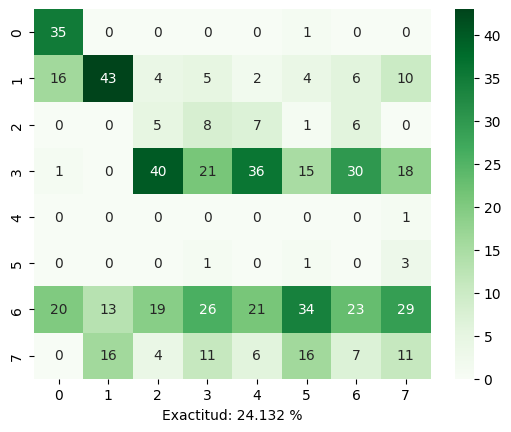

              precision    recall  f1-score   support

           0       0.49      0.97      0.65        36
           1       0.60      0.48      0.53        90
           3       0.07      0.19      0.10        27
           4       0.29      0.13      0.18       161
           6       0.00      0.00      0.00         1
           9       0.01      0.20      0.03         5
          10       0.32      0.12      0.18       185
          11       0.15      0.15      0.15        71

    accuracy                           0.24       576
   macro avg       0.24      0.28      0.23       576
weighted avg       0.33      0.24      0.26       576



In [41]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [42]:
X

,rms_1,iemg_1,mav_1,wl_1,rms_2,iemg_2,mav_2,wl_2,rms_3,iemg_3,...,br_13,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14
0,-0.508471,-0.334379,-0.474685,-0.365001,0.203067,0.622490,0.464191,0.718506,0.781012,1.067671,...,-0.358781,0.294789,-0.022609,-0.731409,-0.582285,-0.561003,-0.637018,0.213679,0.097178,0.005800
1,-0.226793,-0.187686,-0.100745,-0.196744,0.630278,0.606234,0.750028,0.734254,0.928085,0.833736,...,-0.179969,0.567566,-0.016048,-0.796978,-0.473502,-0.821766,-0.977871,-0.200686,-0.133866,-0.195930
2,-0.933566,-1.049538,-0.928539,-0.898295,-0.381916,-0.709021,-0.515328,-0.658709,0.467712,-0.021190,...,0.153159,0.107242,-0.023301,-1.058951,-0.654807,-1.180638,-0.125739,-0.529188,0.092798,-0.090585
3,-0.525981,-0.248551,-0.382579,-0.308140,0.323892,0.567533,0.419516,0.644103,0.575543,0.841956,...,-0.217881,0.269919,-0.022801,-0.871867,-0.618546,-0.530021,-0.296165,-0.665226,-0.126806,-0.017411
4,-0.729794,-0.705661,-0.694717,-0.665518,0.208256,0.160228,0.241409,0.209976,0.353366,0.294437,...,0.064363,0.104339,-0.025483,-0.760587,-0.400980,-0.845002,-0.807445,-1.103533,-0.133255,0.017764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2779,-1.137497,-1.498220,-1.581585,-1.368357,-1.719572,-1.699039,-1.758168,-1.617813,-1.384979,-1.402476,...,0.527665,-0.536451,-0.029997,1.143683,1.121979,1.223030,1.067247,1.948886,-0.764663,-0.580531
2780,-1.085909,-1.105744,-1.250588,-1.140963,-1.522981,-1.440719,-1.541834,-1.407126,-1.362295,-1.301262,...,-0.153308,-0.535345,-0.029997,1.148218,1.013196,1.749720,0.555968,0.784624,-0.581957,-0.596337
2781,-1.349833,-1.624235,-1.721603,-1.442006,-1.680581,-1.693788,-1.755290,-1.618829,-1.449118,-1.438558,...,0.082505,-0.536535,-0.029997,1.145557,1.230761,1.308230,0.385541,3.084898,-0.596001,-0.638377
2782,-1.055652,-1.069872,-1.209751,-1.089379,-1.553691,-1.465935,-1.563298,-1.438298,-1.320504,-1.279701,...,-0.287051,-0.537967,-0.029997,1.064051,1.230761,1.486375,1.237674,1.922606,-0.774549,-0.488487
